In [2]:
import pandas as pd

from matplotlib import pyplot as plt

plt.rcParams["font.family"] = "Arial"

from upsetplot import UpSet

# Loading and Processing Meta Data

In [3]:
meta = pd.read_csv("../../data/fay_meta_nov_upset.csv", index_col=0)

## Upset plot with Catplots

In [4]:
def add_above_average_indicators(data_df, top_features, quantile_threshold=0.50):
    """
    Adds binary indicators to the DataFrame indicating whether each of
    the top features is above the median for that feature.

    Parameters:
    - data_df: The original pandas DataFrame.
    - top_features: A list of strings representing the column names for the top features.

    Returns:
    - A modified DataFrame with additional columns indicating whether the values of the top features
      are above their respective medians and sets these indicators as part of the index.
    """
    # Ensure the top_features are within the DataFrame columns
    top_features = [feature for feature in top_features if feature in data_df.columns]
    print(top_features)

    # Compute whether each value is above the median for its column
    # above_df = data_df[top_features] > data_df[top_features].median()
    above_df = data_df[top_features] > data_df[top_features].quantile(
        quantile_threshold
    )

    # Rename the columns to indicate these are 'above median' indicators
    above_df = above_df.rename(columns=lambda x: x + " > median")

    # Concatenate the original DataFrame with the new binary indicators
    updated_df = pd.concat([data_df, above_df], axis=1)

    # Set the new binary indicators as part of the index
    updated_df = updated_df.set_index(list(above_df.columns))

    return updated_df

In [5]:
upset_feats = [
    "fast_food_fg_eaten",
    "meat_fg_eaten",
    "fiber_eaten",
    "vegetables_fruits",
]
meta_upset = add_above_average_indicators(meta, upset_feats, quantile_threshold=0.50)

## Renaming the columns for better visualization
meta_upset.rename(
    columns={
        "age": "Age",
        "bmi": "BMI",
        "shannon_entropy": "Shannon",
    },
    inplace=True,
)

meta_upset.index.names = [
    "Fast foods eaten > median",
    "Meat eaten > median",
    "Fiber eaten > median",
    "Vegetables/Fruits > median",
]

meta_upset

['fast_food_fg_eaten', 'meat_fg_eaten', 'fiber_eaten', 'vegetables_fruits']


sample-id  \
Fast foods eaten > median Meat eaten > median Fiber eaten > median Vegetables/Fruits > median                
True                      False               True                 True                        sample30556   
False                     True                False                False                       sample30820   
                          False               True                 True                        sample15995   
True                      False               False                True                        sample30850   
False                     True                False                True                        sample16008   
...                                                                                                    ...   
True                      False               False                False                       sample33580   
                          True                True                 True                        sample30821   
                                              False                False                       sample30847   
                          False               False                False                       sample33584   
                          True                False                False                       sample33585   

                                                                                                 id  \
Fast foods eaten > median Meat eaten > median Fiber eaten > median Vegetables/Fruits > median         
True                      False               True                 True                        1939   
False                     True                False                False                       2509   
                          False               True                 True                        1140   
True                      False               False                True                        2544   
False                     True                False                True                        1637   
...                                                                                             ...   
True                      False               False                False                       2655   
                          True                True                 True                        2517   
                                              False                False                       2507   
                          False               False                False                       2653   
                          True                False                False                       2652   

                                                                                              subject_app_key  \
Fast foods eaten > median Meat eaten > median Fiber eaten > median Vegetables/Fruits > median                   
True                      False               True                 True                                ce3m4w   
False                     True                False                False                               qrh38g   
                          False               True                 True                                kz2eh8   
True                      False               False                True                                curus8   
False                     True                False                True                                qf5fwf   
...                                                                                                       ...   
True                      False               False                False                               qda49t   
                          True                True                 True                                phzbkm   
                                              False                False                               mbrack   
                          False               False                False           

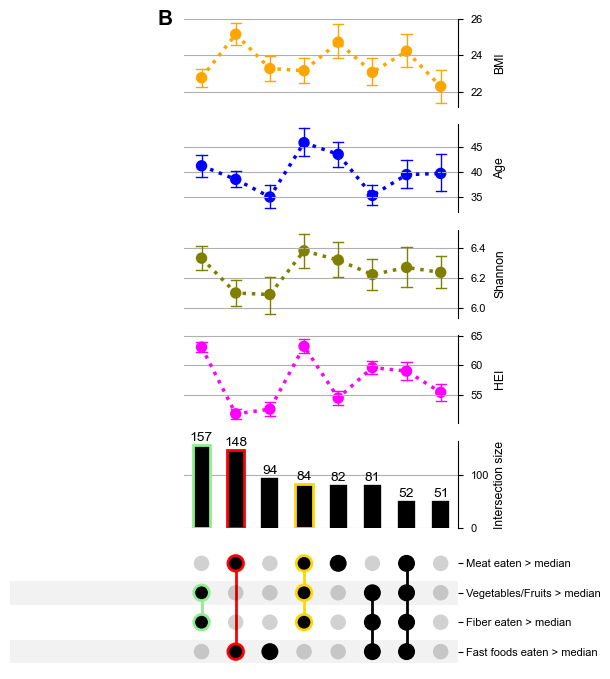

In [6]:
upset = UpSet(
    meta_upset,
    subset_size="count",
    totals_plot_elements=0,
    intersection_plot_elements=3,
    show_counts=True,
    show_percentages=False,
    orientation="horizontal",
    facecolor="black",
    min_subset_size=50,
    sort_by="cardinality",
)

upset.style_subsets(
    present=["Vegetables/Fruits > median", "Fiber eaten > median"],
    absent=["Fast foods eaten > median", "Meat eaten > median"],
    edgecolor="lightgreen",
    linewidth=2,
)

upset.style_subsets(
    present=["Meat eaten > median", "Fast foods eaten > median"],
    absent=["Vegetables/Fruits > median", "Fiber eaten > median"],
    edgecolor="red",
    linewidth=2,
)

upset.style_subsets(
    present=[
        "Meat eaten > median",
        "Vegetables/Fruits > median",
        "Fiber eaten > median",
    ],
    absent=["Fast foods eaten > median"],
    edgecolor="gold",
    linewidth=2,
)

plot_kws = {
    "markers": "o",
    "linestyles": "dotted",
    "errwidth": 1,
    "capsize": 0.3,
    "join": True,
    "estimator": "mean",
}

upset.add_catplot(value="HEI", kind="point", elements=3, color="magenta", **plot_kws)
upset.add_catplot(value="Shannon", kind="point", elements=3, color="olive", **plot_kws)
upset.add_catplot(value="Age", kind="point", elements=3, color="blue", **plot_kws)
upset.add_catplot(value="BMI", kind="point", elements=3, color="orange", **plot_kws)

with plt.style.context("seaborn-paper"):
    upset.plot()
    plt.text(
        -0.1,
        1.1,
        "B",
        transform=plt.gca().transAxes,
        fontsize=15,
        verticalalignment="top",
        horizontalalignment="left",
        weight="bold",
    )

    # Access the scatter plot axes and move y-axis labels and spine to the right
    fig = plt.gcf()
    for ax in fig.axes:
        if hasattr(ax, "collections"):
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            ax.spines["right"].set_position(("outward", 0))
            ax.spines["left"].set_color("none")
            ax.spines["right"].set_visible(True)
            ax.spines["right"].set_color("black")

    plt.savefig(
        "../../figures/gut_diversity_analysis/upset_plot.png",
        dpi=300,
        bbox_inches="tight",
    )